## Acquire and clean oil price data ##

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np

oil_price = yf.download("CL=F", start="2000-01-01", end="2026-04-22")['Close']
oil_vol = yf.download("^OVX", start="2000-01-01", end="2026-04-22")['Close']
oil_price = oil_price.rename(columns={'CL=F': 'Oil_Price'})
oil_vol = oil_vol.rename(columns={'^OVX': 'Oil_Vol'})

/var/folders/zj/nnv8j1rs1qd_bp87z98pn66w0000gn/T/ipykernel_22913/1916595036.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  oil_price = yf.download("CL=F", start="2000-01-01", end="2026-04-22")['Close']
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  1 of 1 completed
/var/folders/zj/nnv8j1rs1qd_bp87z98pn66w0000gn/T/ipykernel_22913/1916595036.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  oil_vol = yf.download("^OVX", start="2000-01-01", end="2026-04-22")['Close']
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed i

In [2]:
import numpy as np
oil_vol['Oil_Vol'] = oil_vol['Oil_Vol'].astype(float)
oil_price['Oil_Price'] = oil_price['Oil_Price'].astype(float)

oil_vol['Oil_Vol'] = oil_vol['Oil_Vol'] / 100
oil_df = pd.merge(oil_price, oil_vol, left_index=True, right_index=True)
oil_df['Oil_Price'] = oil_df['Oil_Price'].mask(oil_df['Oil_Price'] < 0, np.nan)
oil_df['Oil_Price'] = oil_df['Oil_Price'].ffill()
oil_df


Ticker,Oil_Price,Oil_Vol
Date,,
2007-05-10,61.810001,0.2709
2007-05-11,62.369999,0.2641
2007-05-14,62.459999,0.2723
2007-05-15,63.169998,0.2789
2007-05-16,62.549999,0.2707
...,...,...
2026-04-15,91.290001,0.7223
2026-04-16,94.690002,0.7304
2026-04-17,83.849998,0.6901


In [3]:
from fredapi import Fred
import datetime
import numpy as np

start = datetime.datetime(2000, 1, 1)
end = datetime.datetime(2026, 4, 22)
fred = Fred(api_key="38cb01394acc36b6a9f9178338c51d8d")

r_series = fred.get_series('DGS1MO', start, end)
rf_df = r_series.to_frame(name='rf_rate')
rf_df['rf_rate'] = (rf_df['rf_rate']/100).ffill()
rf_df['rf'] = np.log(1 + rf_df['rf_rate'])
rf_df = rf_df.reset_index()
rf_df = rf_df.rename(columns={'index': 'Date'})

oil_data = oil_df.merge(rf_df[['Date', 'rf']], on='Date')

## Option Pricing

In [4]:
import numpy as np
from scipy.stats import norm

def Oil_Pricer_Call(F, K, r, sigma, T=30/365):
    d1 = (np.log(F / K) + (r+ 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    call_price = np.exp(-r * T) * (F * norm.cdf(d1) - K * norm.cdf(d2))
    
    return call_price

def Oil_Pricer_Put(F, K, r, sigma, T=30/365):
    d1 = (np.log(F / K) + (r+ 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    put_price = np.exp(-r * T) * (K * norm.cdf(-d2) - F * norm.cdf(-d1))
    
    return put_price

def get_vega(F, K, r, sigma, T=30/365):
    d1 = (np.log(F/K) + (r+0.5*sigma**2*T)) / (sigma*np.sqrt(T))
    vega = F * np.exp(-r*T) * norm.pdf(d1) * np.sqrt(T)
    return vega

calls = []
puts = []
strikes = []
vega = []

for i in range(len(oil_data)):
    legit_strike = round(oil_data['Oil_Price'].iloc[i] * 2) / 2
    strikes.append(legit_strike)
    calls.append(Oil_Pricer_Call(oil_data['Oil_Price'].iloc[i], legit_strike, oil_data['rf'].iloc[i], oil_data['Oil_Vol'].iloc[i]))
    puts.append(Oil_Pricer_Put(oil_data['Oil_Price'].iloc[i], legit_strike, oil_data['rf'].iloc[i], oil_data['Oil_Vol'].iloc[i]))
    vega.append(get_vega(oil_data['Oil_Price'].iloc[i], legit_strike, oil_data['rf'].iloc[i], oil_data['Oil_Vol'].iloc[i]))

oil_data['ATM Call Price'] = calls
oil_data['ATM Put Price'] = puts
oil_data['Strikes'] = strikes
oil_data['Vega'] = vega
#oil_data.to_csv('Oil_data.csv')
oil_data


,Date,Oil_Price,Oil_Vol,rf,ATM Call Price,ATM Put Price,Strikes,Vega
0,2007-05-10,61.810001,0.2709,0.046597,1.814767,2.004039,62.0,5.884782
1,2007-05-11,62.369999,0.2641,0.046406,1.811856,1.941362,62.5,5.851816
2,2007-05-14,62.459999,0.2723,0.046120,1.915869,1.955719,62.5,5.866425
3,2007-05-15,63.169998,0.2789,0.046788,2.087570,1.918224,63.0,5.793061
4,2007-05-16,62.549999,0.2707,0.046215,1.950703,1.900894,62.5,5.789913
...,...,...,...,...,...,...,...,...
4760,2026-04-15,91.290001,0.7223,0.036525,7.409231,7.618601,91.5,10.040403
4761,2026-04-16,94.690002,0.7304,0.036235,7.958710,7.769273,94.5,10.361121
4762,2026-04-17,83.849998,0.6901,0.036235,6.518403,6.667958,84.0,9.211820
4763,2026-04-20,89.610001,0.7379,0.036235,7.575798,7.466125,89.5,9.817762


## Plot log returns and volatility (both realized and GARCH conditional) ##

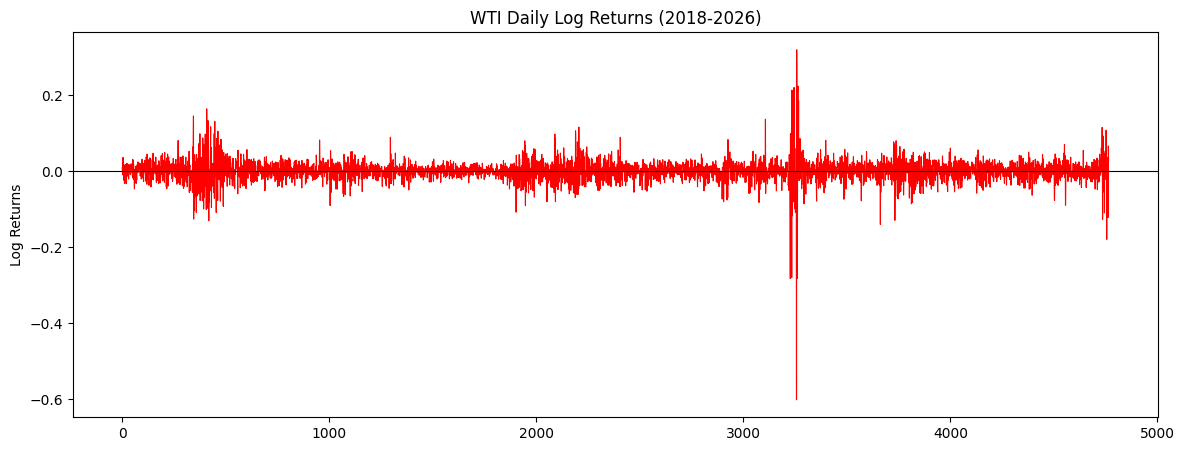

In [5]:
import matplotlib.pyplot as plt
prices = oil_data['Oil_Price']
log_returns = np.log(prices / prices.shift(1)).dropna()

plt.figure(figsize=(14, 5))
plt.plot(log_returns.index, log_returns, color='red', linewidth=0.8)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('WTI Daily Log Returns (2018-2026)')
plt.ylabel('Log Returns')
plt.show()

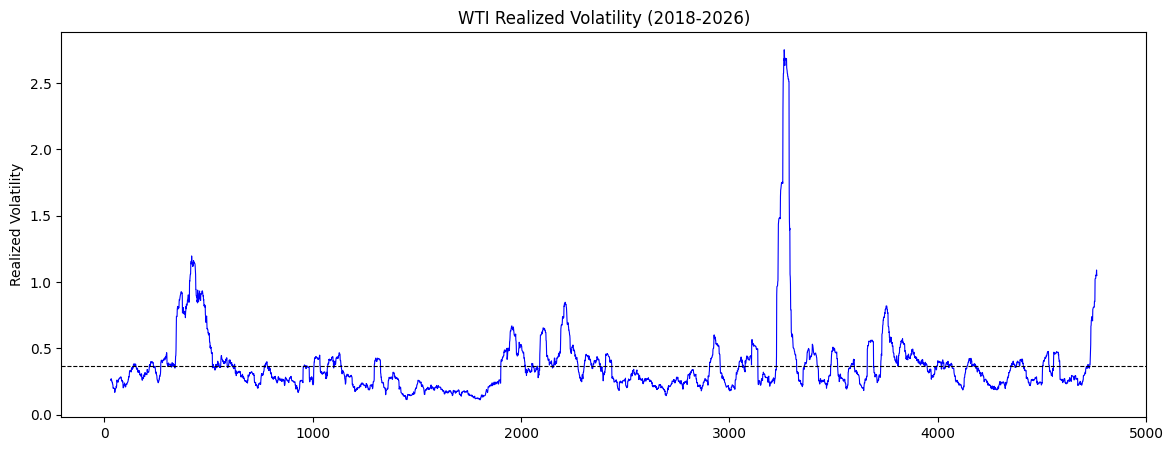

In [6]:
realized_volatility = log_returns.rolling(window=30).std() * np.sqrt(252)
realized_mean_vol = realized_volatility.mean()
plt.figure(figsize=(14, 5))
plt.plot(realized_volatility.index, realized_volatility, color='blue', linewidth=0.8)
plt.axhline(realized_mean_vol, color='black', linewidth=0.8, linestyle='--')
plt.title('WTI Realized Volatility (2018-2026)')
plt.ylabel('Realized Volatility')
plt.show()

## Garch Model Fitting and Data Prepreation for Strategy

In [7]:
from arch import arch_model

log_returns = log_returns * 10
log_returns = log_returns.squeeze()

split_idx = int(len(log_returns) * 0.50)

model = arch_model(log_returns, mean='Constant', vol='Garch', p=1, q=1, dist='t')

fitted_model = model.fit(last_obs=split_idx, disp="off")

forecasts = fitted_model.forecast(horizon=30, start=split_idx)

garch_volatility = np.sqrt(forecasts.variance['h.30'].dropna()) /10 * np.sqrt(252)

garch_mean_vol = garch_volatility.mean()

oil_data = oil_data.iloc[split_idx:]
oil_data['Forecested Vol'] = garch_volatility
oil_data['Difference'] = (oil_data['Oil_Vol'] - oil_data['Forecested Vol'])
rolling_mean = oil_data['Difference'].rolling(window=150).mean()
rolling_std = oil_data['Difference'].rolling(window=150).std()

oil_data['Z_Score'] = (oil_data['Difference'] - rolling_mean) / rolling_std

oil_data = oil_data.dropna()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.06315. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


## Initial Exploration

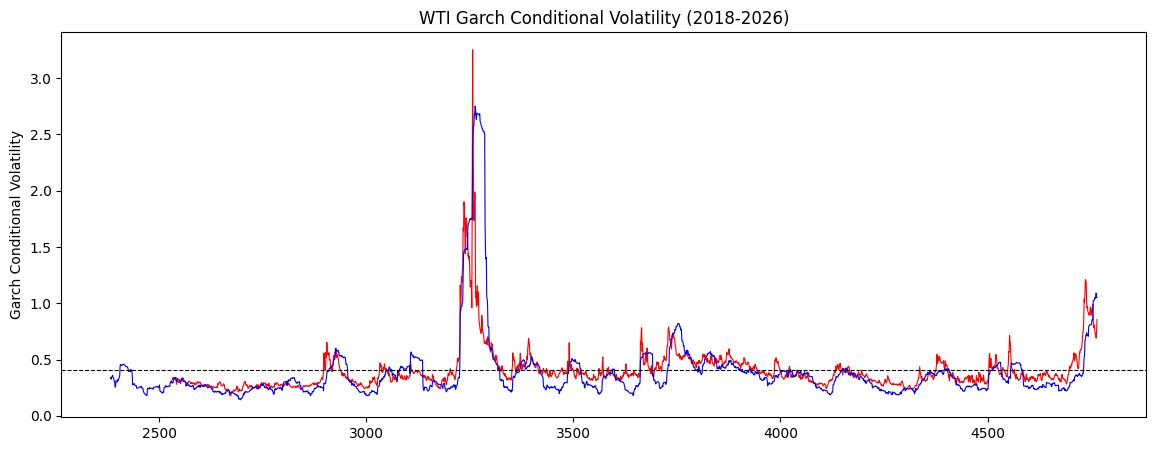

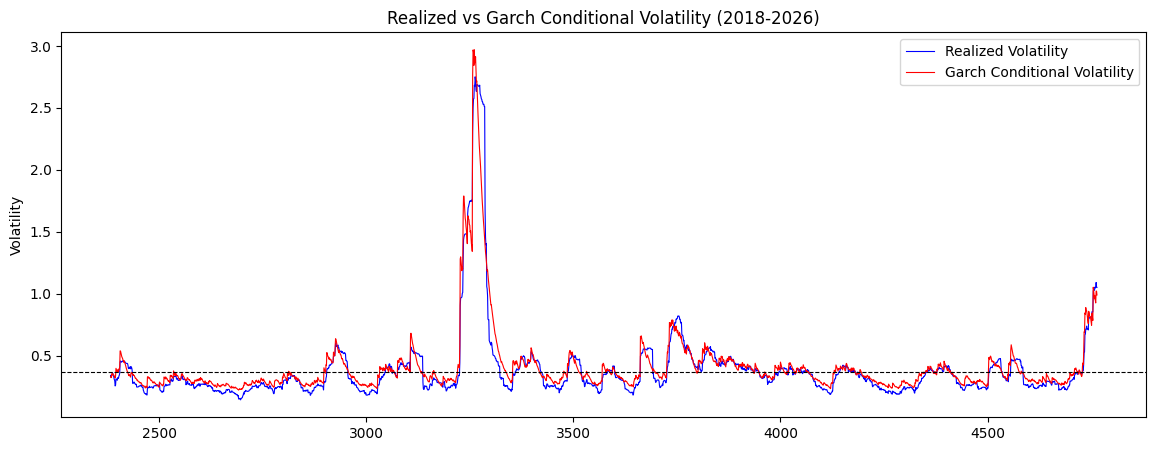

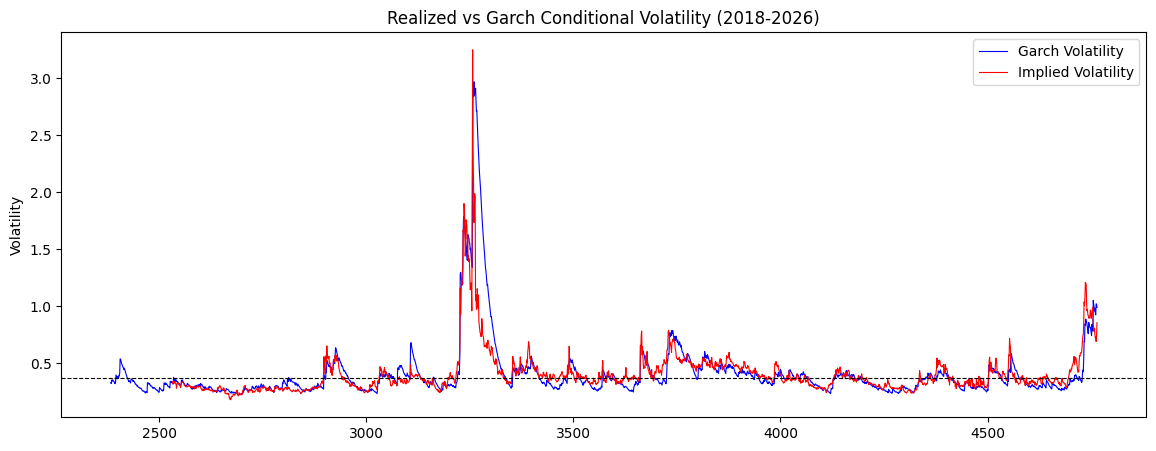

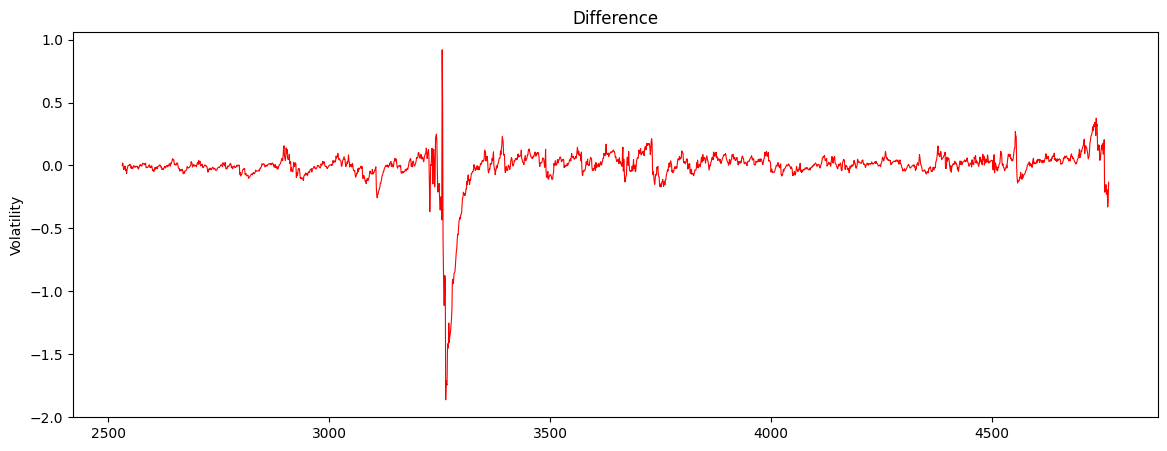

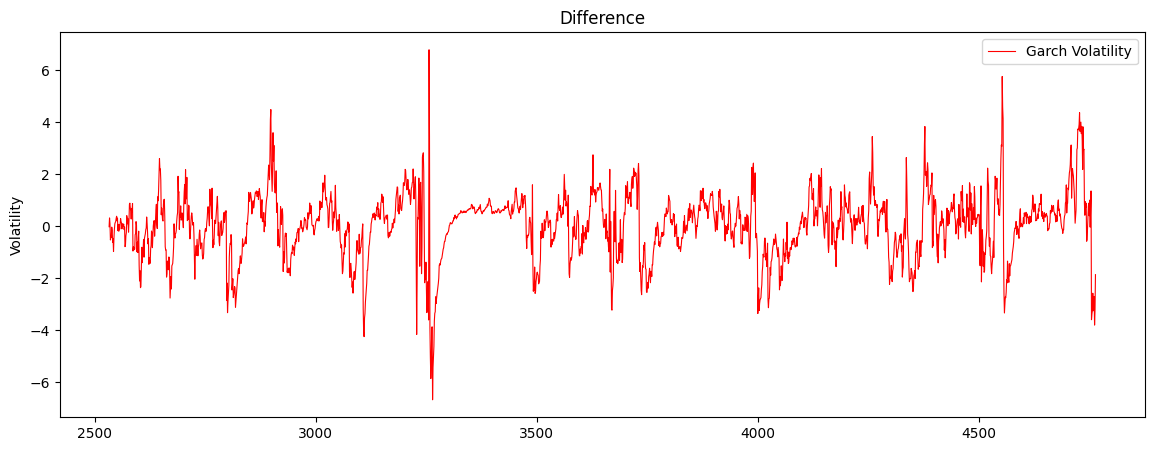

In [8]:
OVX_vol = oil_data['Oil_Vol']
realized_volatility = realized_volatility.iloc[split_idx:]

plt.figure(figsize=(14, 5))
plt.plot(OVX_vol.index, OVX_vol, color='red', linewidth=0.8)
plt.plot(realized_volatility.index, realized_volatility, color='blue', linewidth=0.8)
plt.axhline(garch_mean_vol, color='black', linewidth=0.8, linestyle='--')
plt.title('WTI Garch Conditional Volatility (2018-2026)')
plt.ylabel('Garch Conditional Volatility')
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(realized_volatility.index, realized_volatility, color='blue', linewidth=0.8)
plt.plot(garch_volatility.index, garch_volatility, color='red', linewidth=0.8)
plt.axhline(realized_mean_vol, color='black', linewidth=0.8, linestyle='--')
plt.title('Realized vs Garch Conditional Volatility (2018-2026)')
plt.ylabel('Volatility')
plt.legend(['Realized Volatility', 'Garch Conditional Volatility'])
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(garch_volatility.index, garch_volatility, color='blue', linewidth=0.8)
plt.plot(OVX_vol.index, OVX_vol, color='red', linewidth=0.8)
plt.axhline(realized_mean_vol, color='black', linewidth=0.8, linestyle='--')
plt.title('Realized vs Garch Conditional Volatility (2018-2026)')
plt.ylabel('Volatility')
plt.legend(['Garch Volatility', 'Implied Volatility'])
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(OVX_vol.index, oil_data['Difference'], color='red', linewidth=0.8)
plt.title('Difference')
plt.ylabel('Volatility')
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(oil_data['Z_Score'], color='red', linewidth=0.8)
plt.title('Difference')
plt.ylabel('Volatility')
plt.legend(['Garch Volatility', 'Implied Volatility'])
plt.show()


## Initial Testing

In [9]:
import numpy as np
import pandas as pd

# Calculate future price and realized move
oil_data['Future_Price'] = oil_data['Oil_Price'].shift(-30)
oil_data['Realized_Move'] = np.abs(oil_data['Future_Price'] - oil_data['Strikes'])

oil_data['Straddle_Price'] = oil_data['ATM Call Price'] + oil_data['ATM Put Price']

# Generate signals
upper = 1
lower = -1.5
oil_data['Signal'] = 0
oil_data.loc[oil_data['Z_Score'] > upper, 'Signal'] = 1
oil_data.loc[oil_data['Z_Score'] < lower, 'Signal'] = -1

# Calculate P&L per contract (dollar gain/loss)
oil_data['PnL'] = 0.0
oil_data.loc[oil_data['Signal'] == 1, 'PnL'] = oil_data['Realized_Move'] - oil_data['Straddle_Price']
oil_data.loc[oil_data['Signal'] == -1, 'PnL'] = oil_data['Straddle_Price'] - oil_data['Realized_Move']

# Return per trade (as % of straddle premium paid)
oil_data['Trade_Return'] = oil_data['PnL'] / oil_data['Straddle_Price']

# Filter valid trades
#valid_trades = oil_data.loc[(oil_data['Straddle_Price'] > 0) & (~oil_data['Future_Price'].isna()) & (oil_data['Signal'] != 0)].copy()
valid_trades = oil_data.copy()
returns = valid_trades['Trade_Return'].dropna()

# Annualize assuming ~8.4 trades per year (252 days / 30-day holding)
trades_per_year = 252/30
sharpe = np.sqrt(trades_per_year) * returns.mean() / returns.std()

print('Mean Return per Trade:', returns.mean())
print('Annualized Return:', returns.mean() * trades_per_year)
print('Std Dev (per trade):', returns.std())
print('Annualized Std Dev:', returns.std() * np.sqrt(trades_per_year))
print('Sharpe Ratio:', sharpe)

Mean Return per Trade: 0.11090061329410957
Annualized Return: 0.9315651516705203
Std Dev (per trade): 0.7839623079024347
Annualized Std Dev: 2.2721386317252694
Sharpe Ratio: 0.40999485623954596


2233


(array([2.000e+00, 1.000e+00, 2.000e+00, 2.000e+00, 5.000e+00, 7.000e+00,
        1.000e+01, 1.600e+01, 7.500e+01, 8.000e+01, 1.693e+03, 8.900e+01,
        8.400e+01, 5.600e+01, 1.400e+01, 1.100e+01, 6.000e+00, 9.000e+00,
        1.100e+01, 6.000e+00, 1.000e+01, 8.000e+00, 7.000e+00, 3.000e+00,
        3.000e+00, 1.000e+00, 3.000e+00, 2.000e+00, 1.000e+00, 1.000e+00]),
 array([-3.86303834, -3.5033638 , -3.14368927, -2.78401473, -2.4243402 ,
        -2.06466566, -1.70499113, -1.34531659, -0.98564205, -0.62596752,
        -0.26629298,  0.09338155,  0.45305609,  0.81273062,  1.17240516,
         1.53207969,  1.89175423,  2.25142876,  2.6111033 ,  2.97077783,
         3.33045237,  3.6901269 ,  4.04980144,  4.40947597,  4.76915051,
         5.12882505,  5.48849958,  5.84817412,  6.20784865,  6.56752319,
         6.92719772]),
 <BarContainer object of 30 artists>)

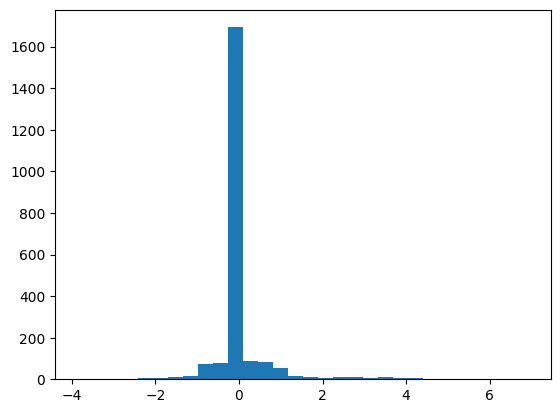

In [10]:
print(len(valid_trades['Trade_Return']))
plt.hist(valid_trades['Trade_Return'], bins=30)

## Z-Score Analysis

This section just test my theory that there is more payoff value on the edges than in the center. It drives the threshold choice in the backtest

Z_SCORE BASKET ANALYSIS - LONG STRADDLES
 Z_Score Range    Trades      Wins      Win Rate    Avg Ret %     Sharpe   Total Ret % 
[ -3.0,  -2.5)      36         15        41.7%       -2.07   %   -0.07       -6.98   %
[ -2.5,  -2.0)      70         30        42.9%       1.74    %    0.07       -1.44   %
[ -2.0,  -1.5)     104         40        38.5%       -6.83   %   -0.27      -29.58   %
[ -1.5,  -1.0)     141         68        48.2%       15.93   %    0.65       83.37   %
[ -1.0,  -0.5)     232        122        52.6%       7.66    %    0.33       39.43   %
[ -0.5,   0.0)     338        133        39.3%      -10.02   %   -0.41      -79.28   %
[  0.0,   0.5)     480        214        44.6%       5.94    %    0.20       1.53    %
[  0.5,   1.0)     414        180        43.5%       8.93    %    0.28       0.61    %
[  1.0,   1.5)     189        113        59.8%       67.33   %    1.23      1283.27  %
[  1.5,   2.0)      90         56        62.2%      103.88   %    1.67      627.36   %
[

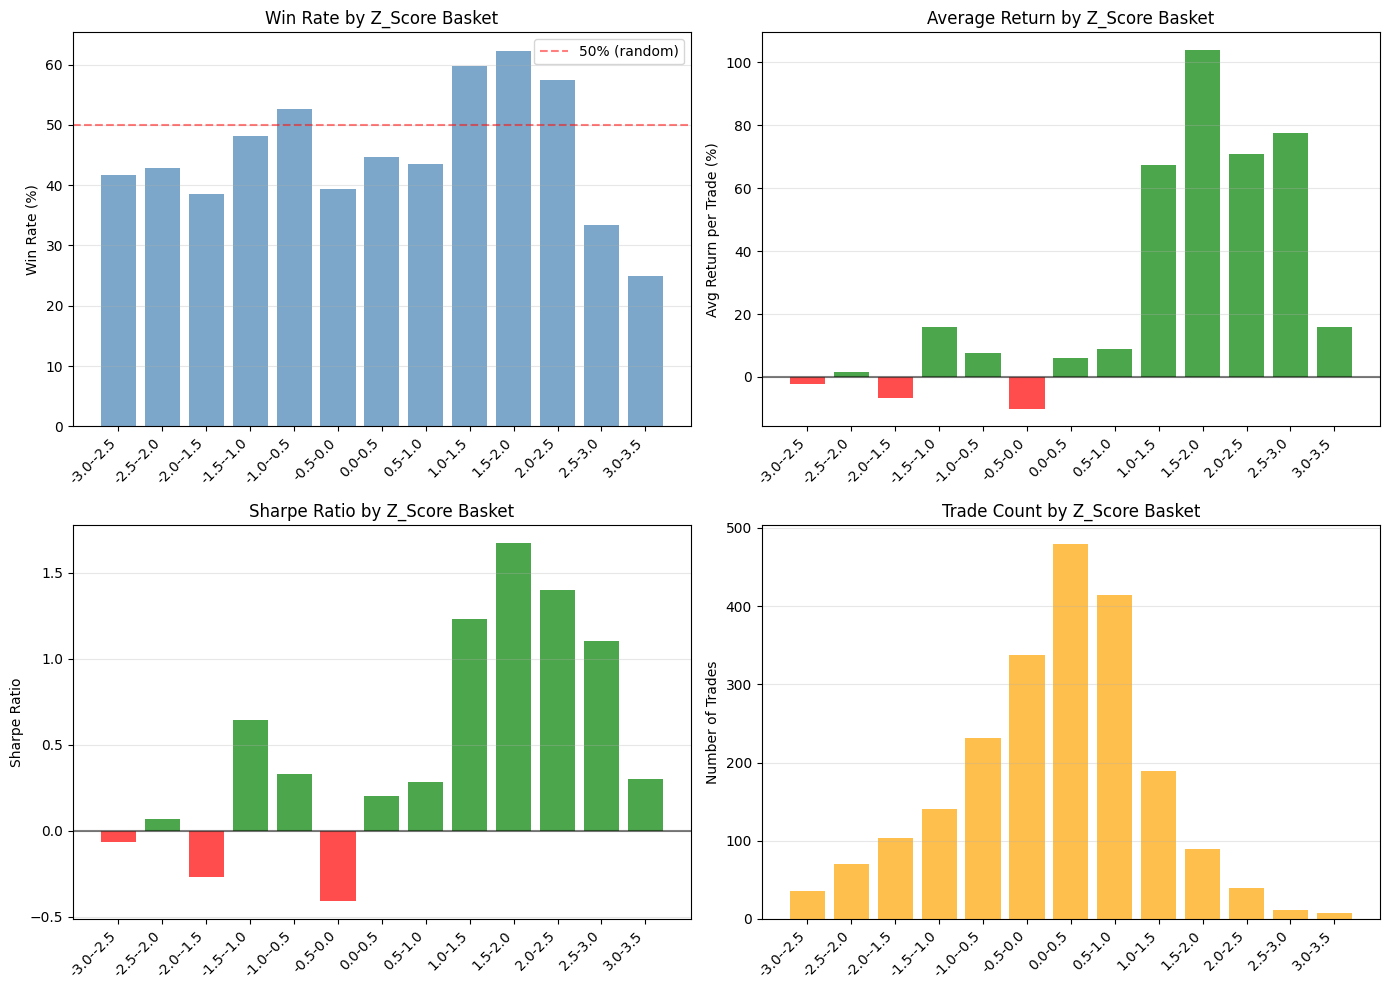

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = oil_data.copy()
df = df.sort_index().reset_index(drop=True)

HOLD_DAYS = 30
INITIAL_CAPITAL = 1_000_000
ALLOC_PER_TRADE = 1 / HOLD_DAYS
TCOST = 0.00

# Precompute forward values ---
df['Future_Price'] = df['Oil_Price'].shift(-HOLD_DAYS)
df['Straddle_Price'] = df['ATM Call Price'] + df['ATM Put Price']

# Function to run backtest for a specific Z_Score range ---
def run_backtest_with_basket(df, z_min, z_max):
    """
    Run backtest for trades within a specific Z_Score range
    
    Args:
        df: DataFrame with all data
        z_min: Lower bound of Z_Score basket
        z_max: Upper bound of Z_Score basket
    """
    
    df_temp = df.copy()
    df_temp['Signal'] = 0
    
    # Long straddles when Z_Score is in range [z_min, z_max)
    mask = (df_temp['Z_Score'] >= z_min) & (df_temp['Z_Score'] < z_max)
    df_temp.loc[mask, 'Signal'] = 1
    
    # Identify valid trades ---
    trades = []
    for i in range(len(df_temp) - HOLD_DAYS):
        row = df_temp.iloc[i]
        
        if row['Signal'] == 0:
            continue
        if row['Straddle_Price'] <= 0 or pd.isna(df_temp.iloc[i + HOLD_DAYS]['Oil_Price']):
            continue
        
        trades.append({
            'entry_idx': i,
            'exit_idx': i + HOLD_DAYS,
            'premium': row['Straddle_Price'],
            'strike': row['Strikes'],
            'signal': row['Signal'],
            'z_score': row['Z_Score']
        })
    
    if len(trades) == 0:
        return None
    
    trades_df = pd.DataFrame(trades)
    
    # Build daily portfolio ---
    n = len(df_temp)
    equity = np.full(n, INITIAL_CAPITAL, dtype=float)
    daily_pnl = np.zeros(n)
    
    open_positions = []
    pnl_list = [] 
    
    for t in range(n):
        current_equity = equity[t-1] if t > 0 else INITIAL_CAPITAL
        
        # ENTRY: Check for new trades
        new_trades_today = trades_df[trades_df['entry_idx'] == t]
        
        for _, trade in new_trades_today.iterrows():
            capital_per_trade = current_equity * ALLOC_PER_TRADE
            contracts = capital_per_trade / trade['premium']
            
            # Get future price at exit
            exit_idx = int(trade['exit_idx'])
            if exit_idx < len(df_temp):
                exit_price = df_temp.iloc[exit_idx]['Oil_Price']
                realized_move = abs(exit_price - trade['strike'])
                
                # P&L per contract (long straddle)
                pnl_per_contract = realized_move - trade['premium']
                pnl_per_contract -= TCOST * trade['premium']
                
                pnl_list.append({
                    'pnl': contracts * pnl_per_contract,
                    'pnl_pct': pnl_per_contract / trade['premium'],
                    'premium': trade['premium'],
                    'realized_move': realized_move,
                    'z_score': trade['z_score']
                })
                
                open_positions.append({
                    'exit_idx': exit_idx,
                    'contracts': contracts,
                    'pnl_per_contract': pnl_per_contract
                })
        
        # EXIT: Close any trades expiring today
        today_pnl = 0
        still_open = []
        
        for pos in open_positions:
            if pos['exit_idx'] == t:
                today_pnl += pos['contracts'] * pos['pnl_per_contract']
            else:
                still_open.append(pos)
        
        open_positions = still_open
        daily_pnl[t] = today_pnl
        
        # Update equity
        if t > 0:
            equity[t] = equity[t-1] + daily_pnl[t]
    
    # Calculate stats
    if len(pnl_list) == 0:
        return None
    
    pnl_df = pd.DataFrame(pnl_list)
    
    total_pnl = pnl_df['pnl'].sum()
    num_trades = len(pnl_df)
    num_wins = (pnl_df['pnl'] > 0).sum()
    win_rate = num_wins / num_trades if num_trades > 0 else 0
    
    avg_return = pnl_df['pnl_pct'].mean()
    std_return = pnl_df['pnl_pct'].std()
    
    # Sharpe
    sharpe = np.sqrt(252/30) * avg_return / std_return if std_return > 0 else 0
    
    # Final equity
    final_equity = equity[-1]
    total_return = (final_equity - INITIAL_CAPITAL) / INITIAL_CAPITAL
    
    return {
        'z_min': z_min,
        'z_max': z_max,
        'num_trades': num_trades,
        'num_wins': num_wins,
        'win_rate': win_rate,
        'avg_return_pct': avg_return * 100,
        'std_return_pct': std_return * 100,
        'sharpe': sharpe,
        'total_pnl': total_pnl,
        'total_return_pct': total_return * 100,
        'final_equity': final_equity
    }


# Define baskets
baskets = [
    (-3.0, -2.5),
    (-2.5, -2.0),
    (-2.0, -1.5),
    (-1.5, -1.0),
    (-1.0, -0.5),
    (-0.5, 0.0),
    (0.0, 0.5),
    (0.5, 1.0),
    (1.0, 1.5),
    (1.5, 2.0),
    (2.0, 2.5),
    (2.5, 3.0),
    (3.0, 3.5),
]

# Run backtest for each basket
results = []

print("="*110)
print("Z_SCORE BASKET ANALYSIS - LONG STRADDLES")
print("="*110)
print(f"{'Z_Score Range':^15} {'Trades':^10} {'Wins':^10} {'Win Rate':^12} {'Avg Ret %':^12} {'Sharpe':^10} {'Total Ret %':^12}")
print("="*110)

for z_min, z_max in baskets:
    result = run_backtest_with_basket(df, z_min, z_max)
    if result and result['num_trades'] > 0:
        results.append(result)
        basket_label = f"[{z_min:>5.1f}, {z_max:>5.1f})"
        print(f"{basket_label:^15} {result['num_trades']:^10} {result['num_wins']:^10} {result['win_rate']:^11.1%} {result['avg_return_pct']:^11.2f}% {result['sharpe']:^10.2f} {result['total_return_pct']:^11.2f}%")

print("="*110)

if results:
    df_results = pd.DataFrame(results)
    
    print("\n" + "="*110)
    print("SUMMARY TABLE")
    print("="*110)
    print(df_results[['z_min', 'z_max', 'num_trades', 'win_rate', 'avg_return_pct', 'sharpe', 'total_return_pct']].to_string(index=False))
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    basket_labels = [f"{z_min:.1f}-{z_max:.1f}" for z_min, z_max in zip(df_results['z_min'], df_results['z_max'])]
    
    # Win Rate
    axes[0, 0].bar(range(len(df_results)), df_results['win_rate'] * 100, color='steelblue', alpha=0.7)
    axes[0, 0].axhline(y=50, color='red', linestyle='--', alpha=0.5, label='50% (random)')
    axes[0, 0].set_ylabel('Win Rate (%)')
    axes[0, 0].set_title('Win Rate by Z_Score Basket')
    axes[0, 0].set_xticks(range(len(df_results)))
    axes[0, 0].set_xticklabels(basket_labels, rotation=45, ha='right')
    axes[0, 0].grid(True, alpha=0.3, axis='y')
    axes[0, 0].legend()
    
    # Avg Return
    colors = ['green' if x > 0 else 'red' for x in df_results['avg_return_pct']]
    axes[0, 1].bar(range(len(df_results)), df_results['avg_return_pct'], color=colors, alpha=0.7)
    axes[0, 1].axhline(y=0, color='black', linestyle='-', alpha=0.5)
    axes[0, 1].set_ylabel('Avg Return per Trade (%)')
    axes[0, 1].set_title('Average Return by Z_Score Basket')
    axes[0, 1].set_xticks(range(len(df_results)))
    axes[0, 1].set_xticklabels(basket_labels, rotation=45, ha='right')
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    
    # Sharpe Ratio
    colors = ['green' if x > 0 else 'red' for x in df_results['sharpe']]
    axes[1, 0].bar(range(len(df_results)), df_results['sharpe'], color=colors, alpha=0.7)
    axes[1, 0].axhline(y=0, color='black', linestyle='-', alpha=0.5)
    axes[1, 0].set_ylabel('Sharpe Ratio')
    axes[1, 0].set_title('Sharpe Ratio by Z_Score Basket')
    axes[1, 0].set_xticks(range(len(df_results)))
    axes[1, 0].set_xticklabels(basket_labels, rotation=45, ha='right')
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    
    # Number of Trades
    axes[1, 1].bar(range(len(df_results)), df_results['num_trades'], color='orange', alpha=0.7)
    axes[1, 1].set_ylabel('Number of Trades')
    axes[1, 1].set_title('Trade Count by Z_Score Basket')
    axes[1, 1].set_xticks(range(len(df_results)))
    axes[1, 1].set_xticklabels(basket_labels, rotation=45, ha='right')
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    print("\n✓ Chart saved: z_score_baskets.png")
    plt.show()

## Backtest

Going short on the straddle caused us to lose and did not seem to hold any value, so if we use te garch as an anomaly detector, the results are stronger with a 55% win rate, which is a 5% edge on rondomly selecting. It also lets us select more of the big winners. In this backtest the PnL and sharpe are driven by some massive wins in 2020 and of very recent. So, we are able to identify the big winners, but the strategy is not completely robust and fails to work in more stable regimes.

In the backtest I also used vega as a scaler for how much capital to allocate in order to add some sort of risk management. You can feel free to adjust the allocation strategy with other greeks or z-score to see if we can minimize the drawdown better.

OPTIONS BACKTEST RESULTS (VEGA-SCALED ALLOCATION)
Initial Capital:       $           1,000,000
Final Equity:          $          14,888,631
Total Return:                      1388.86%

Trades Generated:                       247
Trades Closed:                          247
Win Rate (% return):                  59.1%
Avg Return/Trade:                    85.56%
Avg Allocation/Trade:                 2.04%

Raw Sharpe Ratio:                      1.49
Realized Sharpe Ratio:                 2.15
Raw Sortino Ratio:                     8.69
Realized Sortino Ratio:                3.27
Max Drawdown:                       -20.82%


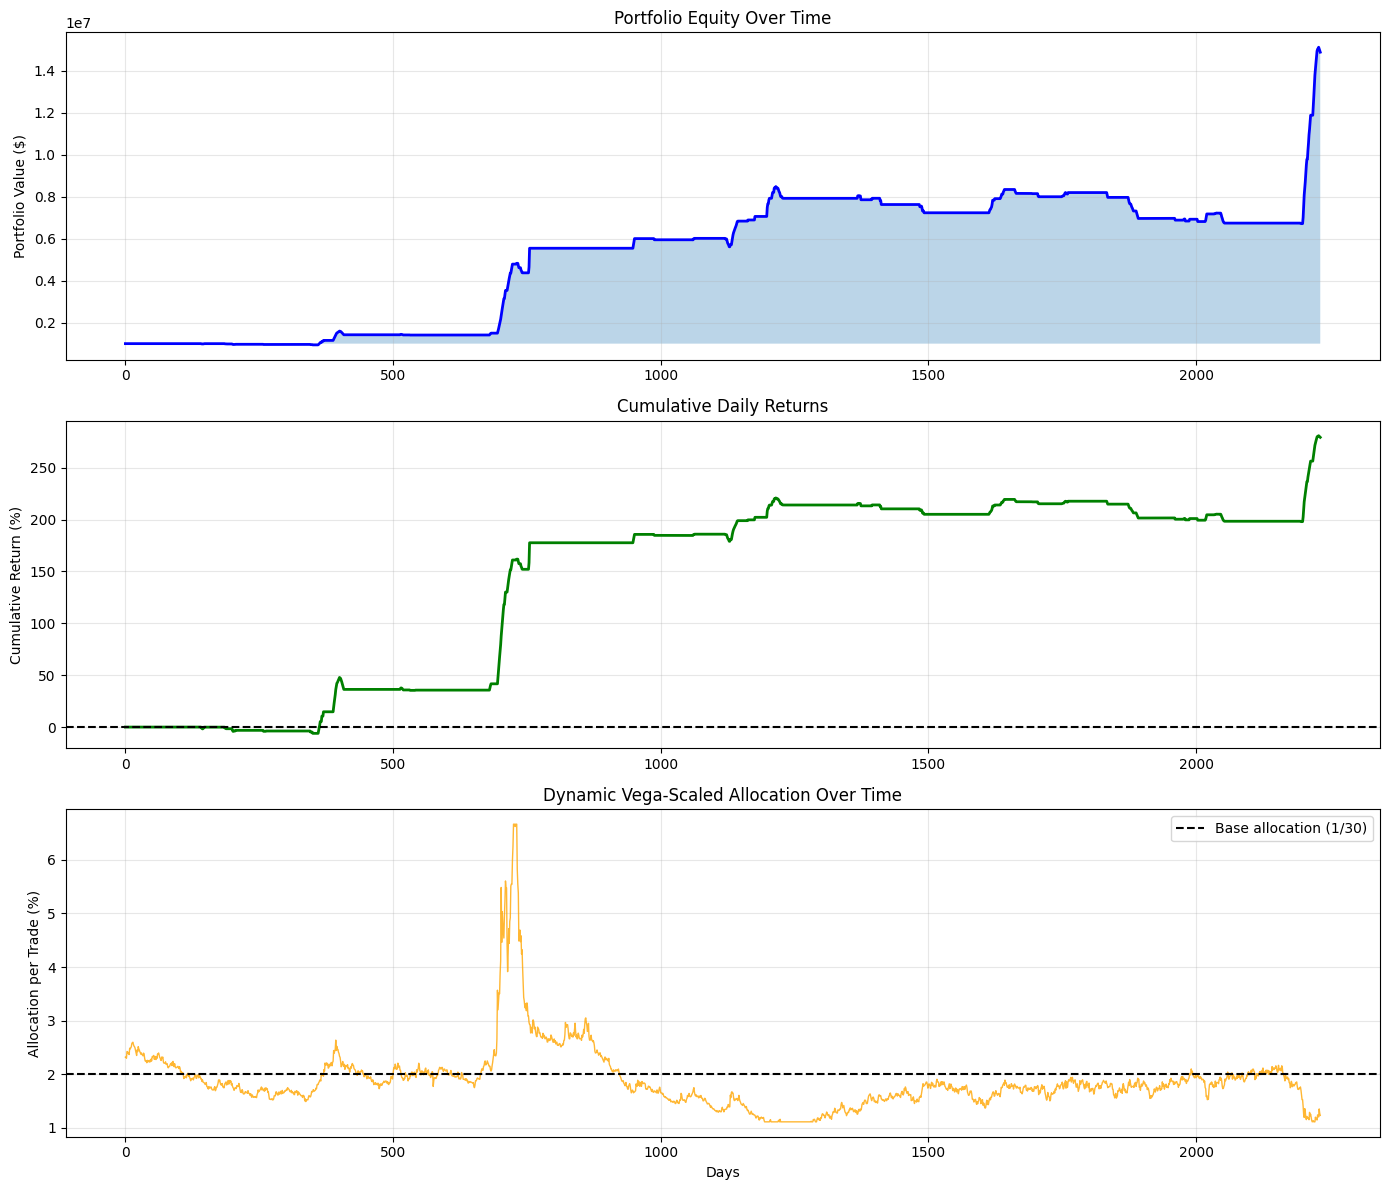

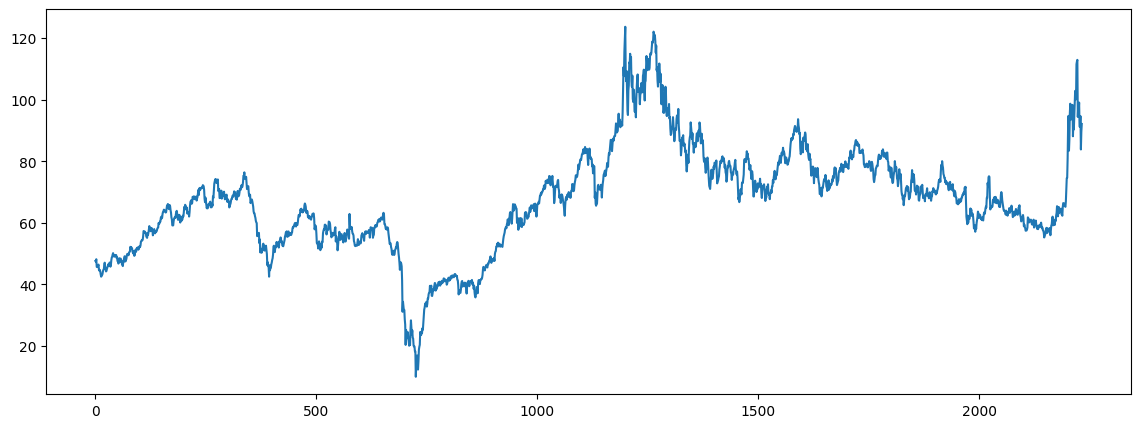

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = oil_data.copy()
df = df.sort_index().reset_index(drop=True)

HOLD_DAYS = 30
INITIAL_CAPITAL = 1_000_000
MAX_POSITIONS = 30
TCOST = 0.00

df['Future_Price'] = df['Oil_Price'].shift(-HOLD_DAYS)
df['Straddle_Price'] = df['ATM Call Price'] + df['ATM Put Price']

# Signal
upper = 1.25
lower = -2

df['Signal'] = 0
#df.loc[df['Z_Score'] < lower, 'Signal'] = 1
df.loc[df['Z_Score'] > upper, 'Signal'] = 1

def vega_scaled_allocation(vega, z_score, base_alloc=1/50, baseline_vega=None):
    if baseline_vega is None or vega <= 0 or baseline_vega <= 0:
        vega_scalar = 1.0
    else:
        vega_scalar = np.clip(baseline_vega/ vega, 0.1, 5.0)

    raw_alloc = base_alloc * vega_scalar

    return np.clip(raw_alloc, 1/90, 1/15)

baseline_vega = df['Vega'].rolling(window=120, min_periods=1).median()
#baseline_vega = df['Vega'].median()

trades = []
for i in range(len(df) - HOLD_DAYS):
    row = df.iloc[i]
    
    if row['Signal'] == 0:
        continue
    if row['Straddle_Price'] <= 0:
        continue
    if pd.isna(df.iloc[i + HOLD_DAYS]['Oil_Price']):
        continue

    baseline = baseline_vega.iloc[i]
    alloc = vega_scaled_allocation(vega=row['Vega'], z_score=row['Z_Score'], baseline_vega=baseline)
    
    trades.append({
        'entry_idx': i,
        'exit_idx': i + HOLD_DAYS,
        'premium': row['Straddle_Price'],
        'strike': row['Strikes'],
        'signal': row['Signal'],
        'allocation': alloc
    })

trades = pd.DataFrame(trades)

if len(trades) == 0:
    print("No valid trades found")
else:
    n = len(df)
    equity = np.full(n, INITIAL_CAPITAL, dtype=float)
    daily_pnl = np.zeros(n)
    
    open_positions = []
    pnl_list = []
    
    for t in range(n):
        current_equity = equity[t-1] if t > 0 else INITIAL_CAPITAL

        new_trades_today = trades[trades['entry_idx'] == t]
        
        for _, trade in new_trades_today.iterrows():
            if len(open_positions) >= MAX_POSITIONS:
                continue
            
            capital_per_trade = current_equity * trade['allocation']
            contracts = capital_per_trade / trade['premium']
            
            open_positions.append({
                'entry_idx': t,
                'exit_idx': int(trade['exit_idx']),
                'contracts': contracts,
                'premium': trade['premium'],
                'strike': trade['strike'],
                'signal': trade['signal'],
                'allocation': trade['allocation']
            })
        
        today_pnl = 0
        still_open = []
        
        for pos in open_positions:
            if pos['exit_idx'] == t:
                exit_price = df.iloc[t]['Oil_Price']
                realized_move = abs(exit_price - pos['strike'])
                
                if pos['signal'] == 1:
                    pnl_per_contract = realized_move - pos['premium']
                else:
                    pnl_per_contract = pos['premium'] - realized_move
                
                pnl_per_contract -= TCOST * pos['premium']
                
                pnl_dollars = pos['contracts'] * pnl_per_contract
                pnl_pct = pnl_per_contract / pos['premium']
                
                today_pnl += pnl_dollars
                pnl_list.append({
                    'pnl_dollars': pnl_dollars,
                    'pnl_pct': pnl_pct,
                    'portfolio_return': pnl_dollars / current_equity,
                    'allocation_used': pos['allocation']
                })
            else:
                still_open.append(pos)
        
        open_positions = still_open
        daily_pnl[t] = today_pnl
        
        if t > 0:
            equity[t] = equity[t-1] + daily_pnl[t]
    
    equity_series = pd.Series(equity)
    returns = equity_series.pct_change().fillna(0)
    
    if len(pnl_list) > 0:
        pnl_df = pd.DataFrame(pnl_list)
        
        num_wins = (pnl_df['pnl_pct'] > 0).sum()
        win_rate = num_wins / len(pnl_df)

        # Sharpe on daily equity curve — reflects actual allocation sizing
        #print(returns)
        sharpe_lev = np.sqrt(252) * returns.mean() / returns.std() if returns.std() > 0 else 0

        avg_return_pct = pnl_df['pnl_pct'].mean()
        std_return_pct = pnl_df['pnl_pct'].std()
        sharpe = np.sqrt(trades_per_year) * avg_return_pct / std_return_pct if std_return_pct > 0 else 0
        
        cum_max = equity_series.cummax()
        drawdown = (equity_series - cum_max) / cum_max
        mdd = drawdown.min()

        negative_returns = returns[returns < 0]
        downside_std_lev = negative_returns.std() if len(negative_returns) > 0 else 0
        sortino_lev = (np.sqrt(252) * returns.mean() / downside_std_lev) if downside_std_lev > 0 else 0

        negative_pnl = pnl_df[pnl_df['pnl_pct'] < 0]['pnl_pct']
        downside_std_raw = negative_pnl.std() if len(negative_pnl) > 0 else 0
        sortino_raw = (np.sqrt(trades_per_year) * avg_return_pct / downside_std_raw) if downside_std_raw > 0 else 0

        total_return = (equity_series.iloc[-1] - INITIAL_CAPITAL) / INITIAL_CAPITAL
        num_trades = len(trades)
        
        avg_alloc = pnl_df['allocation_used'].mean()
        avg_return_pct = pnl_df['pnl_pct'].mean()
        
        print("="*70)
        print("OPTIONS BACKTEST RESULTS (VEGA-SCALED ALLOCATION)")
        print("="*70)
        print(f"Initial Capital:       ${INITIAL_CAPITAL:>20,.0f}")
        print(f"Final Equity:          ${equity_series.iloc[-1]:>20,.0f}")
        print(f"Total Return:          {total_return:>20.2%}")
        print(f"\nTrades Generated:      {num_trades:>20}")
        print(f"Trades Closed:         {len(pnl_df):>20}")
        print(f"Win Rate (% return):   {win_rate:>20.1%}")
        print(f"Avg Return/Trade:      {avg_return_pct:>20.2%}")
        print(f"Avg Allocation/Trade:  {avg_alloc:>20.2%}")
        print(f"\nRaw Sharpe Ratio:      {sharpe:>20.2f}")
        print(f"Realized Sharpe Ratio: {sharpe_lev:>20.2f}")
        print(f"Raw Sortino Ratio:     {sortino_raw:>20.2f}")
        print(f"Realized Sortino Ratio:{sortino_lev:>20.2f}")
        print(f"Max Drawdown:          {mdd:>20.2%}")
        print("="*70)
        
        fig, axes = plt.subplots(3, 1, figsize=(14, 12))
        
        axes[0].plot(equity_series, linewidth=2, color='blue')
        axes[0].fill_between(range(len(equity_series)), INITIAL_CAPITAL, equity_series, alpha=0.3)
        axes[0].set_ylabel('Portfolio Value ($)')
        axes[0].set_title('Portfolio Equity Over Time')
        axes[0].grid(True, alpha=0.3)
        
        axes[1].plot(returns.cumsum() * 100, linewidth=2, color='green')
        axes[1].axhline(y=0, color='black', linestyle='--')
        axes[1].set_ylabel('Cumulative Return (%)')
        axes[1].set_title('Cumulative Daily Returns')
        axes[1].grid(True, alpha=0.3)

        alloc_series = pd.Series([
            vega_scaled_allocation(df.iloc[i]['Vega'], df.iloc[i]['Z_Score'], baseline_vega=baseline)
            for i in range(len(df))
        ])
        axes[2].plot(alloc_series * 100, linewidth=1, color='orange', alpha=0.8)
        axes[2].axhline(y=(1/50)*100, color='black', linestyle='--', label='Base allocation (1/30)')
        axes[2].set_xlabel('Days')
        axes[2].set_ylabel('Allocation per Trade (%)')
        axes[2].set_title('Dynamic Vega-Scaled Allocation Over Time')
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

plt.figure(figsize=(14, 5))
plt.plot(df['Oil_Price'])

In [18]:
print(len(returns))
print(len(valid_trades['Trade_Return']))
print(returns.mean() * 252)
print(returns.std() * np.sqrt(252))

2233
2233
0.3151823143073587
0.14636014230436917
